In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t

In [43]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):

      dt = t - t0

      # --- защита от dt = 0 ---
      if np.abs(dt) < 1e-10:
          dt = 1e-10

      bx = bxt(x0, t0, params)
      bx_x = bxt_x(x0, t0, params)

      # --- защита от x0 = 0 ---
      if np.abs(x0) < 1e-10:
          x0 = 1e-10

      # --- защита от bx_x = 0 ---
      if np.abs(bx_x) < 1e-10:
          bx_x = 1e-10

      denom = x0 * bx_x

      # --- защита от деления на 0 ---
      if np.abs(denom) < 1e-10:
          denom = 1e-10

      # --- аргумент логарифма ---
      val = 1 + bx / denom * (np.exp(bx_x * dt) - 1)

      # --- защита от log(<=0) ---
      if val <= 1e-10:
          val = 1e-10

      K = 1 / dt * np.log(val)

      # --- защита от K = 0 ---
      if np.abs(K) < 1e-10:
          K = 1e-10

      E = x0 + bx / bx_x * (np.exp(bx_x * dt) - 1)

      V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * dt) - 1)

      # --- защита от отрицательной/нулевой дисперсии ---
      if V <= 1e-10:
          V = 1e-10

      xs = E
      sigma2 = V

      return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2

        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.array([2.5, 1.0, 0.2])
        accuracy = 1e-8
        bounds = [
            (1e-6, None),   # theta1 > 0
            (None, None),   # theta2
            (1e-6, None)    # sigma > 0
        ]
        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx,
                              self.sigmaxt,
                              self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              bounds=bounds,
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t)

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

Task 1. Evaluate the conditional density of the Ornstein-Uhlenbeck process
$$dX_t = (3-X_t)dt+2dW_t, \quad X_0=1, \quad %\theta=(1, 3, 2), \quad
N=100000,
\quad \Delta=1$$ and calculate the
maximum likelihood estimation.  

In [3]:
Nx = 100000
Nt = 300

T = 1

params_OU = np.array([3, 1, 2])

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [4]:
OUp.EulerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.97821139673684
        x: [ 3.008e+00  9.997e-01  2.000e+00]
      nit: 14
      jac: [ 8.242e-05 -1.029e-03  5.599e-04]
     nfev: 64
     njev: 16
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [5]:
OUp.ShojiOzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.97821184983007
        x: [ 3.024e+00  1.000e+00  2.010e+00]
      nit: 15
      jac: [ 2.075e-04 -4.206e-04 -4.954e-03]
     nfev: 68
     njev: 17
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [6]:
OUp.KesslerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.9782067246628
        x: [ 3.022e+00  1.003e+00  2.010e+00]
      nit: 17
      jac: [-7.958e-05  5.849e-03 -2.191e-03]
     nfev: 80
     njev: 20
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Find the maximum likelihood estimators  numerically
 for Ornstein-Uhlenbeck process
 $$
 dX_t = -\theta_2X_tdt + \theta_3dW_t, \quad \theta=(0, 3, 2), \quad
N=1000, \quad \Delta=1
$$
and compare with explicit estimations

$$
\hat{\theta}_{2,n} = -\frac{1}{\Delta}\log \left(\frac{\sum_{i=1}^n X_{i-1}X_i} {\sum_{i=1}^n X^2_{i-1}}\right),
$$
$$
\hat{\theta}_{3,n} = \sqrt{\frac{2\hat{\theta}_{2,n}}
{n(1 - e^{-2\Delta  \hat{\theta}_{2,n}})}
\sum_{i=1}^n (X_i- X_{i-1} e^{-\Delta \hat{\theta}_{2, n}})^2}.
$$

In [7]:
# your code

Task 3. Consider  the Chan-Karolyi-Longstaff-Sanders (CKLS) model
$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$
with $\theta_{1}=1$, $\theta_{2}=2$, $\theta_{3}=0.5$, $\theta_{4}=0.3$.

Use the Euler method and
* generate the sample data $X_{t_i}$ with time step $\Delta t =10^{-4}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.  


In [8]:
Nx = 1
Nt = 10000

T = 1

params_CKLS = np.array([1, 2, 0.5, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

CKLSp = CKLSprocess(params_CKLS, T, Nx, Nt, init_state)

t_data, x_data_CKLS = CKLSp.EulerSolution()

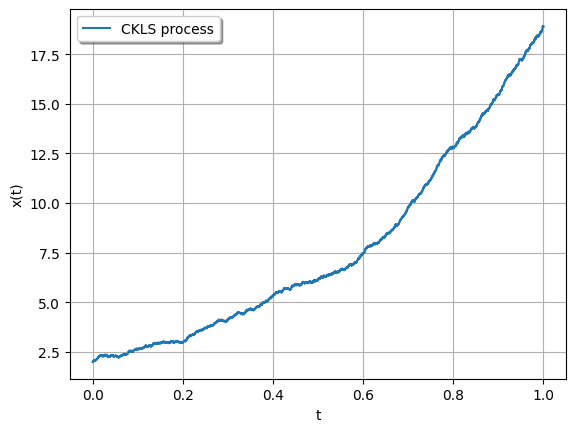

In [9]:
plt.plot(t_data, x_data_CKLS[:,0], label = 'CKLS process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [10]:
CKLSp.EulerEstimation(t_data, x_data_CKLS)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -33219.20808625602
        x: [ 1.117e+00  2.042e+00  5.162e-01  2.849e-01]
      nit: 19
      jac: [-2.183e-03  6.548e-03 -5.384e-02  2.692e-02]
     nfev: 120
     njev: 24
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [11]:
#Confidence intervals
n = 50
result = np.zeros((n, 4))
for k in range(0, n):
    t_data, x_data_CKLS = CKLSp.EulerSolution()
    result[k] = CKLSp.EulerEstimation(t_data, x_data_CKLS).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 4):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 1.1931754839845445 +- 0.18891620881957116 with 95.0% prob
theta1 = 1.972820071250493 +- 0.04946911969842952 with 95.0% prob
theta2 = 0.49803237515282794 +- 0.003059726574667529 with 95.0% prob
theta3 = 0.30294891751739994 +- 0.0033491267905737527 with 95.0% prob


Task 4. Consider the Vasicek model
$$
dX_{t} = \theta_{1} (\theta_{2}- X_{t}) dt + \theta_{3} dW_{t},\qquad X_{0}=5
$$
with $\theta_{1}=3$, $\theta_{2}=2$ and $\theta_{3}=0.5$.

Use the Ozaki method and
*   generate the sample data $X_{t_i}$, time step $\Delta t =10^{-2}$,
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [12]:
Nx = 1
Nt = 100

T = 1

params_OU = np.array([3, 2, 0.5])

x0 = 5
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [13]:
OUp.OzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -169.43565776805985
        x: [ 3.086e+00  2.112e+00  4.463e-01]
      nit: 22
      jac: [-1.421e-05  2.842e-06  5.684e-06]
     nfev: 120
     njev: 30
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [14]:
#Confidence intervals
n = 50
result = np.zeros((n, 3))
for k in range(0, n):
    t_data, x_data_OU = OUp.EulerSolution()
    result[k] = OUp.OzakiEstimation(t_data, x_data_OU).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 3):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 3.179169557841011 +- 0.19001548428441556 with 95.0% prob
theta1 = 1.997754288530878 +- 0.07926594613471045 with 95.0% prob
theta2 = 0.31770670867290773 +- 0.10925107543900447 with 95.0% prob


Task 5. Consider the model
$$
  dX_{t} = a(t)X_{t} dt + \theta_{2}X_{t} dW_{t},\qquad X_{0}=10
$$
with $a(t) = \theta_{1}t$, $\theta_{1}=-2$, $\theta_{2}=0.2$.

Use the Shoji-Ozaki method and:
* generate the sample data $X_{t_i}$ time step $\Delta t =10^{-3}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.

In [15]:
Nx = 1
Nt = 1000

T = 1

params_T5 = np.array([-2, 0.2])

x0 = 5
init_state = x0 * np.ones(Nx)

T5p = Task5process(params_T5, T, Nx, Nt, init_state)

t_data, x_data_T5 = T5p.EulerSolution()

In [16]:
T5p.ShojiOzakiEstimation(t_data, x_data_T5)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -2271.534765920717
        x: [-2.229e+00  2.030e-01]
      nit: 14
      jac: [-7.003e-03 -1.371e+00]
     nfev: 75
     njev: 25
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

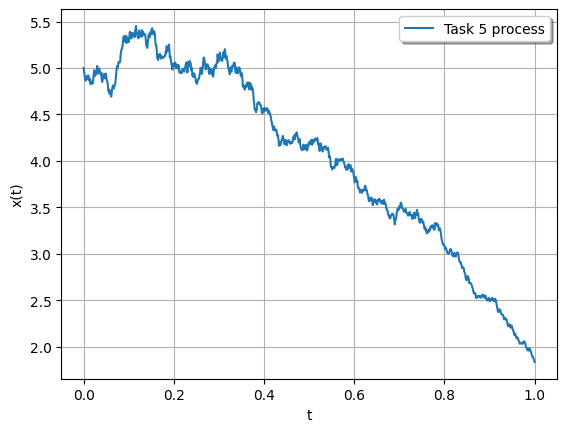

In [17]:
plt.plot(t_data, x_data_T5[:,0], label = 'Task 5 process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [18]:
#Confidence intervals
n = 50
result = np.zeros((n, 2))
for k in range(0, n):
    t_data, x_data_T5 = T5p.EulerSolution()
    result[k] = T5p.ShojiOzakiEstimation(t_data, x_data_T5).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 2):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = -2.05737756834501 +- 0.08812274144979843 with 95.0% prob
theta1 = 0.2002323532705851 +- 0.0011363886246685754 with 95.0% prob


Task 6. Consider the Hull-White (extended Vasicek) model
$$
  dX_{t} = a(t)(b(t)-X_{t}) dt + \sigma(t) dW_{t},\qquad X_{0}=2
$$
with $a(t) = \theta_{1}t$, $b(t)=\theta_{2}\sqrt{t}$, the volatility depends on time $\sigma(t)=\theta_{3}t$.

Generate sample data of $X_t$ with time step $\Delta t =10^{-3}$ and $\theta_{1}=3$, $\theta_{2}=1$ and $\theta_{3}=0.3$, then
use the Kessler method and:
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [19]:
Nx = 1
Nt = 100

T = 1

params_HW = np.array([3, 1, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

HWp = HullWhiteprocess(params_HW, T, Nx, Nt, init_state)

t_data, x_data_HW = HWp.EulerSolution()

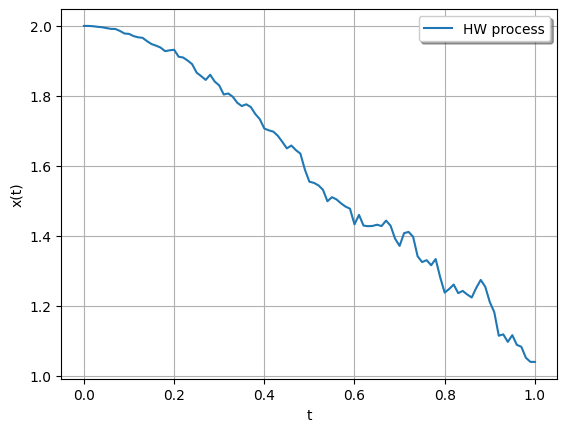

In [20]:
plt.plot(t_data, x_data_HW[:,0], label = 'HW process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [21]:
HWp.KesslerEstimation(t_data, x_data_HW)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -300.46047257792367
        x: [ 2.731e+00  9.008e-01  3.183e-01]
      nit: 14
      jac: [ 8.333e-02 -1.024e-01 -4.264e-02]
     nfev: 136
     njev: 34
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Take a process from previous tasks and approximation method, find the solution, compute confidence intervals, and compare results with baseline.

Plot the graph and table.

Задания по вариантам
1. Байков Илья Павлович OU + Kessler
1. Гонгапшев Астемир Султанович CKLS + Shoji-Ozaki
1. Кудинкина Екатерина Андреевна CKLS + Kessler
1. Кулига Андрей Владимирович Vasicek + Euler
1. Мартыненко Александр Станиславович Vasicek + Shoji-Ozaki
1. Мироманов Даниил Борисович Vasicek + Kessler
1. Паршаков Никита Сергеевич extended Vasicek + Euler
1. Петренко Влада Витальевна extended Vasicek + Ozaki
1. Тумачев Серафим Дмитриевич extended Vasicek + Shoji-Ozaki
1. Хубиев Касымхан Юсуфович model 5 + Euler
1. Ширяева Софья Игоревна model 5 + Ozaki
1. Якунин Сергей Александрович model 5 + Kessler
1. Трофимов Яков Георгиевич CKLS + Ozaki


In [22]:
# your code

Задание 1. Сравнительный анализ точного и численного MLE

1. Для процесса Орнштейна-Уленбека (модель Вазичека) сгенерируйте траекторию процесса, параметры $\theta = (\theta_1, \theta_2, \theta_3)$ укажите самостоятельно.

2. Вычислите оценки параметров двумя способами: аналитически и численно минимизируя функцию отрицательного логарифма правдоподобия (`MLogLik`) с использованием схемы Эйлера.

3. Оцените абсолютную относительную ошибку численного метода по сравнению с аналитическим решением.

4. Сделайте выводы.


In [23]:
def OU_analytical_MLE(t_data, x_data):
    dt = t_data[1] - t_data[0]

    X = x_data[:-1].flatten()
    Y = x_data[1:].flatten()

    n = len(X)

    # оценка beta и mu через линейную регрессию
    Sx = np.sum(X)
    Sy = np.sum(Y)
    Sxx = np.sum(X * X)
    Sxy = np.sum(X * Y)

    beta = (Sxy - Sx * Sy / n) / (Sxx - Sx**2 / n)

    alpha = (Sy - beta * Sx) / n  # это (1 - beta)*mu

    mu = alpha / (1 - beta)

    # theta
    theta = -np.log(beta) / dt

    # sigma
    residuals = Y - alpha - beta * X
    sigma2 = (2 * theta / (1 - beta**2)) * np.mean(residuals**2)
    sigma = np.sqrt(sigma2)

    return np.array([theta, mu, sigma])

In [24]:
params = np.array([2.5, 1.2, 1.8])

Nx = 100000
Nt = 300
T = 1

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

#  аналитическое MLE
analytical = OU_analytical_MLE(t_data, x_data_OU)

# численное
numerical = OUp.EulerEstimation(t_data, x_data_OU).x

# ошибка
error = np.abs(numerical - analytical) / np.abs(analytical)

print("True params:", params)
print("Analytical:", analytical)
print("Numerical:", numerical)
print("Relative error:", error)

True params: [2.5 1.2 1.8]
Analytical: [2.51245451 1.20238962 1.80735711]
Numerical: [2.50228763 1.20246784 1.79981238]
Relative error: [4.04659277e-03 6.50478094e-05 4.17445739e-03]


Аналитический и численный методы оценки параметров процесса  Орнштейна-Уленбека практически совпадают. Относительные ошибки малы и не превышают 1% для каждого из параметров. Небольшие отклонения оценок от точных значений связаны с дискретизацией процесса, стохастичностью данных

Задача 2. Оценивание параметров в семействе моделей CKLS

1. Используя модель Чана-Карольи-Лонгстаффа-Сандерса (CKLS) реализуйте класс `CKLSprocess` и сгенерируйте данные с малым шагом $\Delta t = 10^{-4}$.

2. Примените метод Эйлера для оценки вектора параметров $\theta = (\theta_1, \theta_2, \theta_3, \theta_4)$.

3. Проведите $n=50$ симуляций процесса и постройте 95% доверительные интервалы для каждого параметра, используя t-распределение Стьюдента.

4. Сделайте выводы.



In [25]:
params_true = np.array([0.5, -1.0, 0.3, 0.5])
T = 1
dt = 1e-4
Nt = int(T / dt)   # 10000
Nx = 1             # одна траектория
n_sim = 50
estimates = []

for i in range(n_sim):
    x0 = 1
    init_state = np.array([x0])

    process = CKLSprocess(params_true, T, Nx, Nt, init_state)

    t_data, x_data = process.EulerSolution()

    res = process.EulerEstimation(t_data, x_data)

    estimates.append(res.x)

estimates = np.array(estimates)
mean_est = np.mean(estimates, axis=0)
std_est = np.std(estimates, axis=0, ddof=1)

alpha = 0.05
df = n_sim - 1

t_crit = t.ppf(1 - alpha/2, df)

ci_lower = mean_est - t_crit * std_est / np.sqrt(n_sim)
ci_upper = mean_est + t_crit * std_est / np.sqrt(n_sim)

for i in range(4):
    print(f"θ{i+1}:")
    print("  True:", params_true[i])
    print("  Mean:", mean_est[i])
    print("  95% Доверительный интервал :", (ci_lower[i], ci_upper[i]))
    print()

θ1:
  True: 0.5
  Mean: 0.085999862561291
  95% Доверительный интервал : (np.float64(-0.36186524554481797), np.float64(0.5338649706673999))

θ2:
  True: -1.0
  Mean: -0.42744462697879015
  95% Доверительный интервал : (np.float64(-1.0244137079881905), np.float64(0.16952445403061023))

θ3:
  True: 0.3
  Mean: 0.25171623550350647
  95% Доверительный интервал : (np.float64(0.20495919169015053), np.float64(0.2984732793168624))

θ4:
  True: 0.5
  Mean: 0.4921772486039419
  95% Доверительный интервал : (np.float64(0.47383699792519995), np.float64(0.5105174992826839))



Параметры диффузии θ3, θ4 показали оценку с высокой точностью, получившиеся средние значения близки к точным, доверительные интервалы узкие.
Параметры дрейфа θ1, θ2 имеют широкие доверительные интервалы, что говорит о высокой вариативности и смещении оценок.
Такая разница может объясняться тем, что при малом шаге дискретизации вклад стохастической компоненты превышает вклад детерминированной части. Метод Эйлера для оценки параметров сноса в диффузионных процессах ухудшается\ от систематического смещения, в отличие от оценки параметров волатильности.





Задача 3. Локальная линеаризация (Метод Озаки)

1. Для модели Вазичека с фиксированным $\sigma$ реализуйте оценку параметров методом Озаки.
2.  Сравните результаты метода Озаки с методом Эйлера при различных шагах дискретизации $\Delta t \in \{10^{-1}, 10^{-2}, 10^{-3}\}$.
3. Подтвердите теоретический вывод о том, что методы локальной линеаризации работают лучше метода Эйлера при увеличении шага $\Delta t$.
4. Сделайте выводы.

In [26]:
params_true = np.array([2.0, 1.0, 1.5])
T = 1
Nx = 1
x0 = 1

def run_experiment(dt):
    Nt = int(T / dt)
    init_state = np.array([x0])
    process = OUprocess(params_true, T, Nx, Nt, init_state)
    t_data, x_data = process.EulerSolution()
    #  Euler
    res_euler = process.EulerEstimation(t_data, x_data).x
    #  Ozaki
    res_ozaki = process.OzakiEstimation(t_data, x_data).x
    return res_euler, res_ozaki

dts = [1e-1, 1e-2, 1e-3]
results = {}
for dt in dts:
    euler, ozaki = run_experiment(dt)
    results[dt] = (euler, ozaki)

for dt in dts:
    euler, ozaki = results[dt]

    err_euler = np.abs(euler - params_true)
    err_ozaki = np.abs(ozaki - params_true)

    print(f"\nΔt = {dt}")
    print("Euler error:", err_euler)
    print("Ozaki error:", err_ozaki)


Δt = 0.1
Euler error: [0.6499293  0.86446086 0.21160211]
Ozaki error: [4.17251716 0.51833152 0.06890901]

Δt = 0.01
Euler error: [0.57619531 0.74545144 0.06628904]
Ozaki error: [1.05106235 1.42538287 0.0630184 ]

Δt = 0.001
Euler error: [7.04608374e+00 4.50502569e-01 1.27711749e-03]
Ozaki error: [2.03882452 0.76909244 0.01244539]


При крупном шаге Δt = 0.1 метод Озаки даёт более точные оценки по сравнению с методом Эйлера. С уменьшением шага различия между методами уменьшаются

Сравнение проводилось только на одной реализации процесса, поэтому оценки чувствительны к случайному шуму


Задача 4. Оценивание моделей с временной зависимостью (Метод Кесслера)

1. Рассмотрите расширенную модель Вазичека (модель Халла-Уайта), где коэффициенты зависят от времени.

2. Используйте метод Кесслера и оцените параметры сноса и диффузии по траектории, сгенерированной с параметрами $(3.0, 1.0, 0.3)$, $\Delta t = 10^{-3}$.

3. Рассчитайте матрицу ковариации оценок параметров.

4. Сделайте выводы.


In [44]:
params_true = np.array([3.0, 1.0, 0.3])

T = 10
dt = 1e-3
Nt = int(T / dt)

Nx = 1
x0 = 1

init_state = x0 * np.ones(Nx)

process = HullWhiteprocess(params_true, T, Nx, Nt, init_state)

t_data, x_data = process.EulerSolution()

res = process.KesslerEstimation(t_data, x_data)

estimated_params = res.x

print("True params:", params_true)
print("Estimated params:", estimated_params)

cov_matrix = res.hess_inv.todense()

print("Covariance matrix:")
print(cov_matrix)

True params: [3.  1.  0.3]
Estimated params: [2.49715327 1.01150696 0.30303875]
Covariance matrix:
[[ 1.27753463 -1.13516296  0.53308841]
 [-1.13516296  1.00881809 -0.47365869]
 [ 0.53308841 -0.47365869  0.22245711]]


Параметры дрейфа были оцнены с большей ошибкой, чем коэффициент диффузии, это объясняется стохастической составляющей процесса, которая оказывает более сильное влияние на приращения. Ковариационная матрица показала сильную корреляцию между параметрами дрейфа

Задача 5. Исследование схем наблюдений

1. Проведите эксперимент, сравнивающий точность оценок в зависимости от дизайна эксперимента:
*   Large sample scheme: $\Delta=const$, увеличивающееся $n$ (общее время $T \to \infty$).
*   High-frequency scheme: Фиксированное $T=const$, уменьшающийся шаг $\Delta \to 0$.
2. Установите, как меняется смещение (bias) и дисперсия оценок параметров сноса и диффузии при переходе от одной схемы к другой. Подкрепите выводы иллюстративными графиками.

3. Сделайте выводы.

In [48]:
true_params = np.array([2.0, 1.0, 0.5])

M = 200

Nt_grid = [50, 100, 200, 500] #размер выборки

bias_theta_ls = []
var_theta_ls = []

bias_sigma_ls = []
var_sigma_ls = []

dt = 0.1

for Nt in Nt_grid:

    T = Nt * dt #время наблюдения

    estimates = []

    for _ in range(M): #цикл для независимых экспериментов

        process = OUprocess(
            params=true_params,
            T=T,
            Nx=1,
            Nt=Nt
        )

        t_data, x_data = process.EulerSolution() #генерация траектории

        res = process.EulerEstimation(t_data, x_data) #оценка параметров

        estimates.append(res.x)

    estimates = np.array(estimates)
#извлечение оценок
    theta_hat = estimates[:,0]
    sigma_hat = estimates[:,2]

    bias_theta_ls.append(np.mean(theta_hat) - true_params[0])
    var_theta_ls.append(np.var(theta_hat))

    bias_sigma_ls.append(np.mean(sigma_hat) - true_params[2])
    var_sigma_ls.append(np.var(sigma_hat))

In [49]:
bias_theta_hf = []
var_theta_hf = []

bias_sigma_hf = []
var_sigma_hf = []

T = 10

for Nt in Nt_grid:

    estimates = []

    for _ in range(M):

        process = OUprocess(
            params=true_params,
            T=T,
            Nx=1,
            Nt=Nt
        )

        t_data, x_data = process.EulerSolution()

        res = process.EulerEstimation(t_data, x_data)

        estimates.append(res.x)

    estimates = np.array(estimates)

    theta_hat = estimates[:,0]
    sigma_hat = estimates[:,2]

    bias_theta_hf.append(np.mean(theta_hat) - true_params[0])
    var_theta_hf.append(np.var(theta_hat))

    bias_sigma_hf.append(np.mean(sigma_hat) - true_params[2])
    var_sigma_hf.append(np.var(sigma_hat))

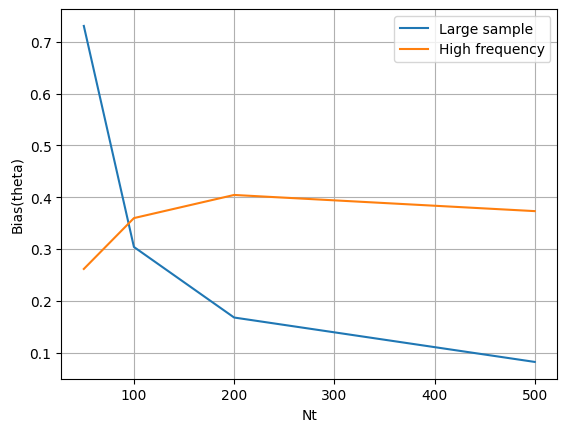

In [50]:
plt.plot(Nt_grid, bias_theta_ls, label='Large sample')
plt.plot(Nt_grid, bias_theta_hf, label='High frequency')

plt.xlabel('Nt')
plt.ylabel('Bias(theta)')
plt.legend()
plt.grid()

Large sample scheme лучше подходит для оценки параметра сноса. Информация о сносе накапливается на длинном горизонте времени
High-frequency scheme не обеспечивает хорошей оценки параметра, при частых наблюдениях смещение остаётся заметным